In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch
from tqdm.auto import tqdm
import torch.nn.functional as F

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.output import*
from lib.cea_lib.data_loader import*


/home/chapuissamuel/Documents/code/RT-Diffusion/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Conditional Diffusion Model on 1D Wavelet Coefficients

Dans ce notebook, le signal 1D $x_0 \in \mathbb{R}^{32}$ est décomposé en ondelettes de Haar au niveau 1 :
$$x_0 \longmapsto (Ca, Ch).$$

L'objectif n'est plus de conditionner la diffusion par un label discret. On utilise directement l'approximation basse fréquence `Ca` comme condition, et le modèle de diffusion apprend à générer le détail haute fréquence `Ch` :
$$p_\theta(Ch \mid Ca).$$

Cela correspond à une factorisation coarse-to-fine : `Ca` fixe la structure basse fréquence du signal, tandis que la diffusion modélise les composantes fines compatibles avec cette structure.


# Chargement du Dataset RT-CEA

On charge un dataset 2D RT-CEA connu, puis on le prétraite en images `32 x 32`. Pour rester dans un modèle 1D, chaque ligne horizontale de chaque image prétraitée est utilisée comme un signal de taille `SIGNAL_SIZE = 32`.

Les labels physiques chargés depuis le fichier HDF5 sont conservés uniquement comme métadonnées éventuelles. Ils ne sont pas utilisés par le modèle : le conditionnement de la diffusion reste `Ca`, et la variable diffusée reste `Ch`.


In [2]:
N = 50000
SIGNAL_SIZE = 32
DATA_FILE = "../data/RTCEA_bimode.hdf5"

# Nombre minimal d'images 32x32 nécessaires si chaque ligne devient un signal 1D.
image_number = N // SIGNAL_SIZE

data_raw, labels_raw = load_RTCEA(DATA_FILE)

try:
    data_norm, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=SIGNAL_SIZE,
    )
except ImportError as exc:
    # Fallback si OpenCV n'est pas disponible : crop/mask avec data_preprocessing,
    # puis resize par interpolation PyTorch.
    if "OpenCV" not in str(exc):
        raise
    data_cropped, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=-1,
    )
    data_tensor = torch.as_tensor(data_cropped, dtype=torch.float32)[:, None]
    data_norm = torch.nn.functional.interpolate(
        data_tensor,
        size=(SIGNAL_SIZE, SIGNAL_SIZE),
        mode="bilinear",
        align_corners=False,
    )[:, 0].numpy()

if data_norm.shape[0] == 0:
    raise ValueError("data_preprocessing n'a retourné aucune image. Vérifier le fichier et les critères de crop.")

# Chaque image (32, 32) fournit 32 signaux 1D de longueur 32.
# On limite à N signaux après aplatissement en lignes.
profile_images = data_norm[:image_number]
profiles = profile_images.reshape(-1, SIGNAL_SIZE)[:N]

# Normalisation globale du dataset 1D pour une échelle compatible avec la diffusion gaussienne.
dataset = torch.as_tensor(profiles, dtype=torch.float32)
signal_mean = dataset.mean()
signal_std = dataset.std().clamp_min(1e-8)
dataset = (dataset - signal_mean) / signal_std

grid = torch.linspace(0, 1, SIGNAL_SIZE)
N = dataset.shape[0]

print("data_raw.shape       =", data_raw.shape)
print("data_norm.shape      =", data_norm.shape)
print("profile_images.shape =", profile_images.shape)
print("dataset.shape        =", dataset.shape)
print("mean/std             =", dataset.mean().item(), dataset.std().item())


data_raw.shape       = (1978, 512, 256)
data_norm.shape      = (1445, 32, 32)
profile_images.shape = (1445, 32, 32)
dataset.shape        = torch.Size([46240, 32])
mean/std             = -3.3659095066695954e-08 1.0


In [3]:
# Optionnel : pour changer le type de profil 1D, remplacer l'extraction par lignes ci-dessus
# par des colonnes, une moyenne verticale, ou une coupe choisie physiquement.


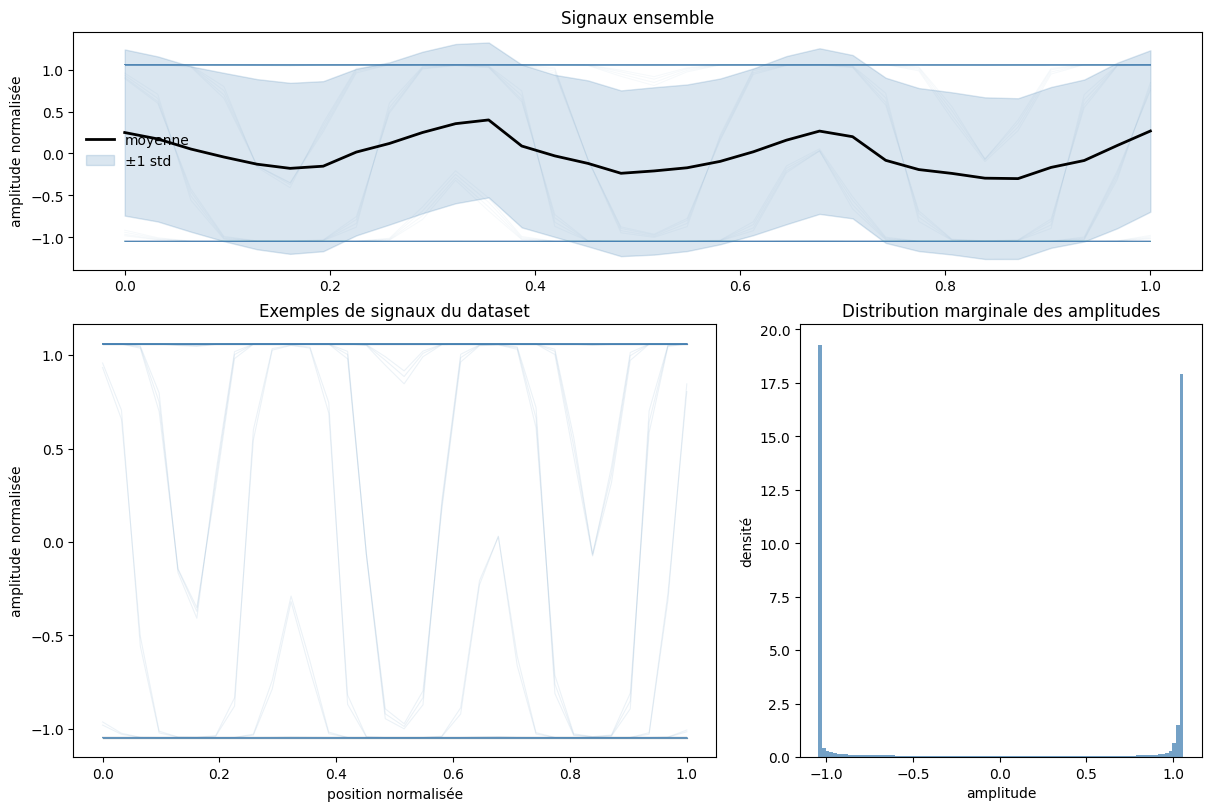

In [4]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.1, 1.0, 1.0],
    width_ratios=[1.6, 1.0],
)

ax_all = fig.add_subplot(gs[0, :])
ax_examples = fig.add_subplot(gs[1:, 0], sharex=ax_all)
ax_dist = fig.add_subplot(gs[1:, 1])

mean_signal = dataset.mean(dim=0)
std_signal = dataset.std(dim=0)

ax_all.plot(grid, dataset[:120].T, color="steelblue", alpha=0.05, linewidth=0.7)
ax_all.plot(grid, mean_signal, color="black", linewidth=2, label="moyenne")
ax_all.fill_between(
    grid.numpy(),
    (mean_signal - std_signal).numpy(),
    (mean_signal + std_signal).numpy(),
    color="steelblue",
    alpha=0.2,
    label="±1 std",
)
ax_all.set_title("Signaux ensemble")
ax_all.set_ylabel("amplitude normalisée")
ax_all.legend(frameon=False)

ax_examples.plot(grid, dataset[:80].T, color="steelblue", alpha=0.10, linewidth=0.8)
ax_examples.set_title("Exemples de signaux du dataset")
ax_examples.set_xlabel("position normalisée")
ax_examples.set_ylabel("amplitude normalisée")

ax_dist.hist(dataset.flatten(), bins=100, density=True, color="steelblue", alpha=0.75)
ax_dist.set_title("Distribution marginale des amplitudes")
ax_dist.set_xlabel("amplitude")
ax_dist.set_ylabel("densité")

plt.show()


## Transformation en wavelet 1D

Dans `wave_data_mining_CEA.py`, les images 2D sont décomposées par `pywt.wavedec2` en quatre blocs au niveau 1 :

- `cA` : approximation basse fréquence ;
- `cH`, `cV`, `cD` : détails horizontal, vertical et diagonal.

Pour un signal 1D, il n'existe pas de directions verticale/diagonale. L'équivalent naturel est donc :

- `cA` : approximation basse fréquence ;
- `cD` : détail haute fréquence.

Par analogie avec ton nommage, on peut appeler le détail 1D `cH` ou `Ch`, mais mathématiquement c'est le coefficient de détail `cD`. Au niveau 1 avec `SIGNAL_SIZE = 32` et l'ondelette de Haar `db1`, on obtient deux vecteurs de taille 16 :
$$x \in \mathbb{R}^{32} \longmapsto (cA_1, cD_1) \in \mathbb{R}^{16} \times \mathbb{R}^{16}.$$


In [5]:
import pywt

WAVELET = "db1"


def data_wavelet_transform_1d(signals, wavelet="db1", level=1):
    """
    Décomposition ondelette 1D de chaque signal.

    Pour level=1, retourne un tenseur de forme (N, 2, L/2) :
    - canal 0 : cA1, approximation basse fréquence ;
    - canal 1 : cD1, détail haute fréquence, noté aussi Ch par analogie avec le cas 2D.

    Pour level>1, PyWavelets retourne des blocs de tailles différentes :
    [cA_level, cD_level, ..., cD1]. On garde donc une liste de tuples plutôt
    qu'un tenseur empilé artificiellement.
    """
    if isinstance(signals, torch.Tensor):
        signals_np = signals.detach().cpu().numpy()
    else:
        signals_np = np.asarray(signals)

    coeffs = [pywt.wavedec(signal, wavelet=wavelet, level=level) for signal in signals_np]

    if level == 1:
        # pywt.wavedec renvoie [cA1, cD1]. Les deux blocs ont la même taille pour db1 et L pair.
        return torch.tensor(
            np.stack([np.stack(sample_coeffs, axis=0) for sample_coeffs in coeffs], axis=0),
            dtype=signals.dtype if isinstance(signals, torch.Tensor) else torch.float32,
        )

    return coeffs


def split_ca_ch(j1):
    """Sépare un tenseur ondelette niveau 1 de forme (N, 2, L/2) en Ca et Ch."""
    ca = j1[:, 0, :]
    ch = j1[:, 1, :]
    return ca, ch


def inverse_wavelet_transform_1d(j1, wavelet="db1"):
    """Reconstruit les signaux depuis un tenseur niveau 1 (N, 2, L/2)."""
    if isinstance(j1, torch.Tensor):
        coeffs_np = j1.detach().cpu().numpy()
    else:
        coeffs_np = np.asarray(j1)

    reconstructed = [pywt.waverec([sample[0], sample[1]], wavelet=wavelet) for sample in coeffs_np]
    reconstructed = np.stack(reconstructed, axis=0)
    return torch.tensor(reconstructed, dtype=j1.dtype if isinstance(j1, torch.Tensor) else torch.float32)


In [6]:
j1 = data_wavelet_transform_1d(dataset, wavelet=WAVELET, level=1)
Ca, Ch = split_ca_ch(j1)

# Décompositions multi-échelles : listes [cA_j, cD_j, ..., cD1] par signal.
j2 = data_wavelet_transform_1d(dataset, wavelet=WAVELET, level=2)
j3 = data_wavelet_transform_1d(dataset, wavelet=WAVELET, level=3)

reconstructed = inverse_wavelet_transform_1d(j1, wavelet=WAVELET)
reconstruction_error = torch.mean((reconstructed[:, :SIGNAL_SIZE] - dataset) ** 2).sqrt()

print("dataset.shape =", dataset.shape)
print("j1.shape      =", j1.shape, "  # (N, 2, SIGNAL_SIZE/2) = (N, [Ca, Ch], 16)")
print("Ca.shape      =", Ca.shape, "  # condition basse fréquence")
print("Ch.shape      =", Ch.shape, "  # variable diffusée haute fréquence")
print("j2[0] shapes  =", [coef.shape for coef in j2[0]])
print("j3[0] shapes  =", [coef.shape for coef in j3[0]])
print("RMSE reconstruction niveau 1 =", reconstruction_error.item())


dataset.shape = torch.Size([46240, 32])
j1.shape      = torch.Size([46240, 2, 16])   # (N, 2, SIGNAL_SIZE/2) = (N, [Ca, Ch], 16)
Ca.shape      = torch.Size([46240, 16])   # condition basse fréquence
Ch.shape      = torch.Size([46240, 16])   # variable diffusée haute fréquence
j2[0] shapes  = [(8,), (8,), (16,)]
j3[0] shapes  = [(4,), (4,), (8,), (16,)]
RMSE reconstruction niveau 1 = 6.741765901097097e-08


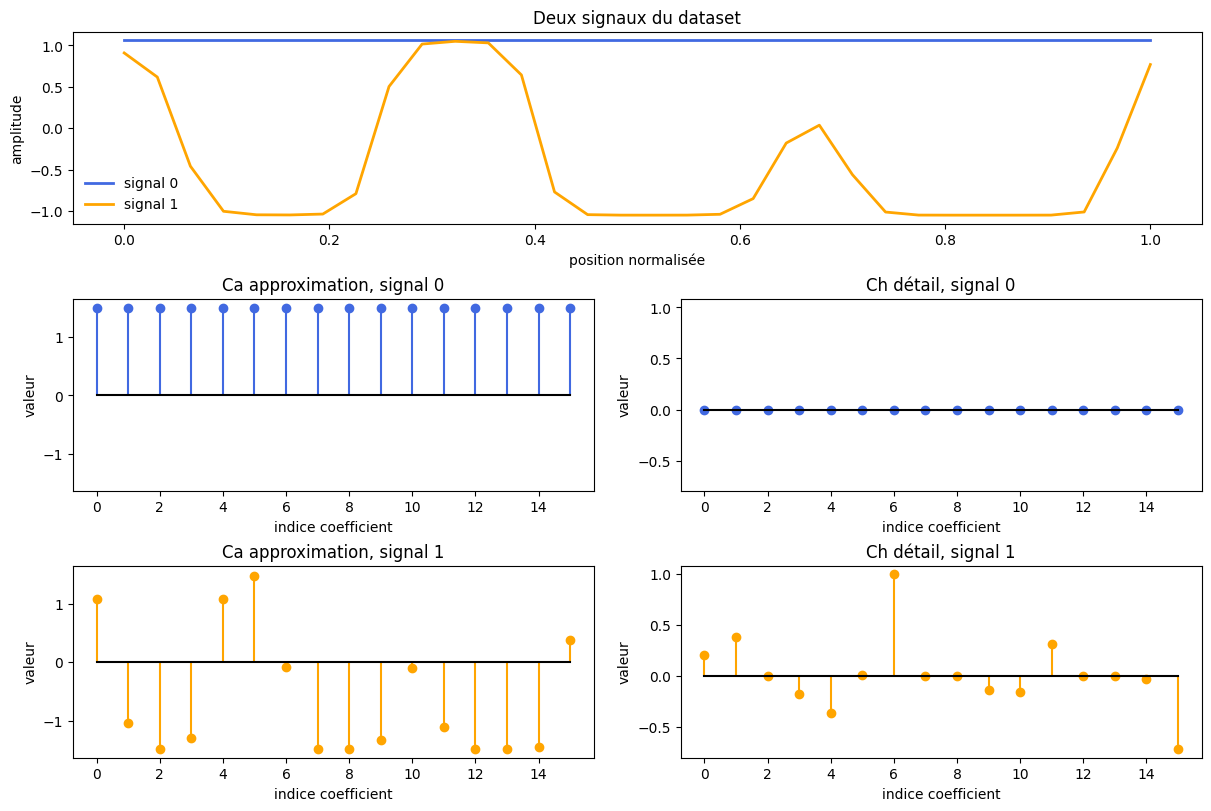

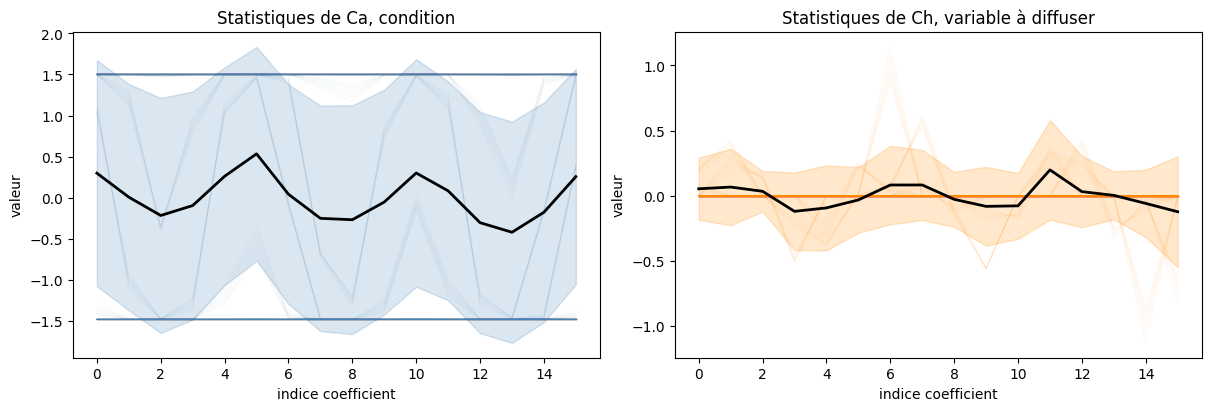

In [7]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.0, 1.0])

idx0 = 0
idx1 = 80
coef_grid = torch.arange(Ca.shape[1])

ax_signal = fig.add_subplot(gs[0, :])
ax_ca0 = fig.add_subplot(gs[1, 0])
ax_ch0 = fig.add_subplot(gs[1, 1], sharex=ax_ca0)
ax_ca1 = fig.add_subplot(gs[2, 0], sharex=ax_ca0, sharey=ax_ca0)
ax_ch1 = fig.add_subplot(gs[2, 1], sharex=ax_ch0, sharey=ax_ch0)

for idx, color, name in [(idx0, "royalblue", "signal 0"), (idx1, "orange", "signal 1")]:
    ax_signal.plot(grid, dataset[idx], color=color, linewidth=2, label=name)

ax_signal.set_title("Deux signaux du dataset")
ax_signal.set_xlabel("position normalisée")
ax_signal.set_ylabel("amplitude")
ax_signal.legend(frameon=False)

for axis, idx, color, title in [
    (ax_ca0, idx0, "royalblue", "Ca approximation, signal 0"),
    (ax_ch0, idx0, "royalblue", "Ch détail, signal 0"),
    (ax_ca1, idx1, "orange", "Ca approximation, signal 1"),
    (ax_ch1, idx1, "orange", "Ch détail, signal 1"),
]:
    coeff = Ca[idx] if "Ca" in title else Ch[idx]
    axis.stem(coef_grid, coeff, linefmt=color, markerfmt="o", basefmt="k-")
    axis.set_title(title)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")

plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ax[0].plot(coef_grid, Ca[:200].T, color="steelblue", alpha=0.05, linewidth=0.8)
ax[0].plot(coef_grid, Ca.mean(dim=0), color="black", linewidth=2)
ax[0].fill_between(
    coef_grid.numpy(),
    (Ca.mean(dim=0) - Ca.std(dim=0)).numpy(),
    (Ca.mean(dim=0) + Ca.std(dim=0)).numpy(),
    color="steelblue",
    alpha=0.2,
)
ax[0].set_title("Statistiques de Ca, condition")

ax[1].plot(coef_grid, Ch[:200].T, color="darkorange", alpha=0.05, linewidth=0.8)
ax[1].plot(coef_grid, Ch.mean(dim=0), color="black", linewidth=2)
ax[1].fill_between(
    coef_grid.numpy(),
    (Ch.mean(dim=0) - Ch.std(dim=0)).numpy(),
    (Ch.mean(dim=0) + Ch.std(dim=0)).numpy(),
    color="darkorange",
    alpha=0.2,
)
ax[1].set_title("Statistiques de Ch, variable à diffuser")

for axis in ax:
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")

plt.show()


## Diffusion Process

Equation du processus de diffusion foward:
$$q(x_{1:T} | x_0) := \prod_{t=1}^{T} q(x_t | x_{t-1})$$
Le processus de diffusion est une chaîne de Markov : pour simuler toute la trajectoire du bruit, il suffit d'appliquer T petites étapes successives et indépendantes, chacune ajoutant un peu de bruit à partir de l'état précédent. 
Ces étapes d'ajouts s'écrivent comme, 
$$ q(x_t | x_{t-1}) := \mathcal{N}(x_t|\sqrt{1-\beta_t} \, x_{t-1};\beta_t \textbf{I}) $$
Ou la moyenne et la variances sont choisi de tel sorte que la sortie de la distribution pour $x_T$ ai une moyenne nulle et une variance unitaire. Et $\beta$ est la quantité de bruit ajouté a chaque étape.

In [8]:
# Parametres
TIME_STEPS = 100
BETA = 0.02

In [ ]:
# Diffusion avec un nombre de pas fixe
def do_diffusion(data, steps=100, beta=0.02):
    """_summary_
    Perform diffusion following equation 1 in diffusion process

    Args:
        data (_type_): Data to apply diffusion on
        steps (int, optional): number of add noise iteration. Defaults to TIME_STEPS.
        beta (float, optional): how much noise is added at each step. Defaults to BETA.

    Returns:
        list: (x(t)) and x(t)
    """
    distributions, samples = [None], [data]
    xt = data
    for t in range(steps):
        q = torch.distributions.Normal(
            np.sqrt(1 - beta) * xt,
            np.sqrt(beta)
        )
        xt = q.sample()

        distributions.append(q)
        samples.append(xt)

    return distributions, samples



def do_diffusion_until_snr(data, snr_threshold=1e-1, beta=0.02):
    """
    Perform diffusion until theoretical SNR falls below a threshold.

    Args:
        data: initial samples x0
        snr_threshold: stop when SNR_t < threshold
        beta: diffusion noise level

    Returns:
        distributions, samples, t
    """

    distributions, samples = [None], [data]
    xt = data

    alpha = 1.0 - beta
    alpha_bar = 1.0

    t = 0

    while True:

        q = torch.distributions.Normal(
            np.sqrt(alpha) * xt,
            np.sqrt(beta)
        )

        xt = q.sample()

        distributions.append(q)
        samples.append(xt)

        t += 1

        alpha_bar *= alpha

        snr = alpha_bar / (1.0 - alpha_bar)

        if snr < snr_threshold:
            break

    return distributions, samples, t

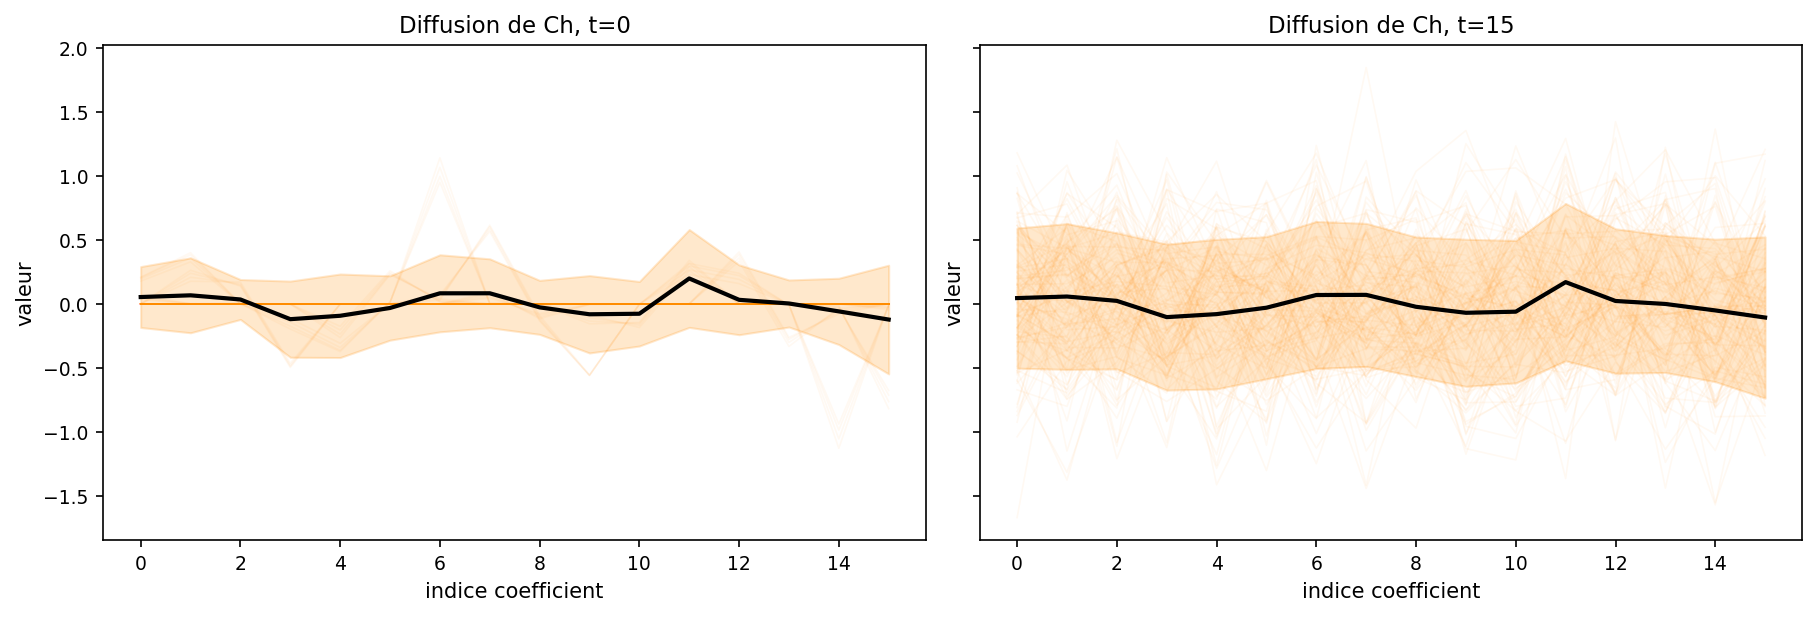

In [32]:


_, samples, T = do_diffusion_until_snr(Ch, snr_threshold=3, beta=BETA)


samples_tensor = torch.stack(samples)
coef_grid = torch.arange(Ch.shape[1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)

for col, time_index in enumerate([0, T]):
    subset = samples_tensor[time_index]
    mean_signal = subset.mean(dim=0)
    std_signal = subset.std(dim=0)
    ax[col].plot(coef_grid, subset[:120].T, color="darkorange", alpha=0.05, linewidth=0.8)
    ax[col].plot(coef_grid, mean_signal, color="black", linewidth=2)
    ax[col].fill_between(
        coef_grid.numpy(),
        (mean_signal - std_signal).numpy(),
        (mean_signal + std_signal).numpy(),
        color="darkorange",
        alpha=0.2,
    )
    ax[col].set_title(f"Diffusion de Ch, t={time_index}")
    ax[col].set_xlabel("indice coefficient")
    ax[col].set_ylabel("valeur")

plt.show()


# Entrainement

Le modèle ne reçoit plus de label discret. Pour chaque signal, on diffuse uniquement `Ch` et on conditionne la prédiction du bruit par `Ca` :
$$\epsilon_\theta(Ch_t, t, Ca).$$

La loss reste la loss DDPM usuelle de prédiction du bruit, mais elle porte seulement sur les coefficients haute fréquence.


In [ ]:
import torch.nn.functional as F

TARGET_DIM = Ch.shape[1]
CONDITION_DIM = Ca.shape[1]
input_dim = TARGET_DIM + 1 + CONDITION_DIM  # Ch bruité + temps normalisé + Ca
hidden_dim = 128

eps_model = torch.nn.Sequential(
    torch.nn.Linear(input_dim, hidden_dim),
    torch.nn.SiLU(),
    torch.nn.Linear(hidden_dim, hidden_dim),
    torch.nn.SiLU(),
    torch.nn.Linear(hidden_dim, hidden_dim),
    torch.nn.SiLU(),
    torch.nn.Linear(hidden_dim, TARGET_DIM),
)

optim = torch.optim.AdamW(
    eps_model.parameters(),
    lr=1e-3,
    weight_decay=1e-6,
)

def compute_loss(ch0, ca_condition, model):
    batch_size = ch0.shape[0]

    t = torch.randint(
        1,
        TIME_STEPS + 1,
        (batch_size, 1),
        device=ch0.device,
        dtype=ch0.dtype,
    )

    alpha_bar = (1 - BETA) ** t
    eps = torch.randn_like(ch0)

    cht = torch.sqrt(alpha_bar) * ch0 + torch.sqrt(1 - alpha_bar) * eps

    xin = torch.cat(
        [
            cht,
            t / TIME_STEPS,
            ca_condition.to(device=ch0.device, dtype=ch0.dtype),
        ],
        dim=1,
    )

    eps_pred = model(xin)

    return F.mse_loss(eps_pred, eps)


In [34]:
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

EPOCHS_NB = 500

train_loader = DataLoader(
    TensorDataset(Ch, Ca),
    batch_size=256,
    shuffle=True,
)

loss_history = []

for epoch in range(EPOCHS_NB):

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS_NB}",
        leave=False,
    )

    for ch_batch, ca_batch in pbar:

        optim.zero_grad()

        loss = compute_loss(
            ch_batch,
            ca_batch,
            eps_model,
        )

        loss.backward()
        optim.step()
        data_norm = data_norm.reshape(data_norm.shape[0], -1)

        loss_history.append(loss.item())

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


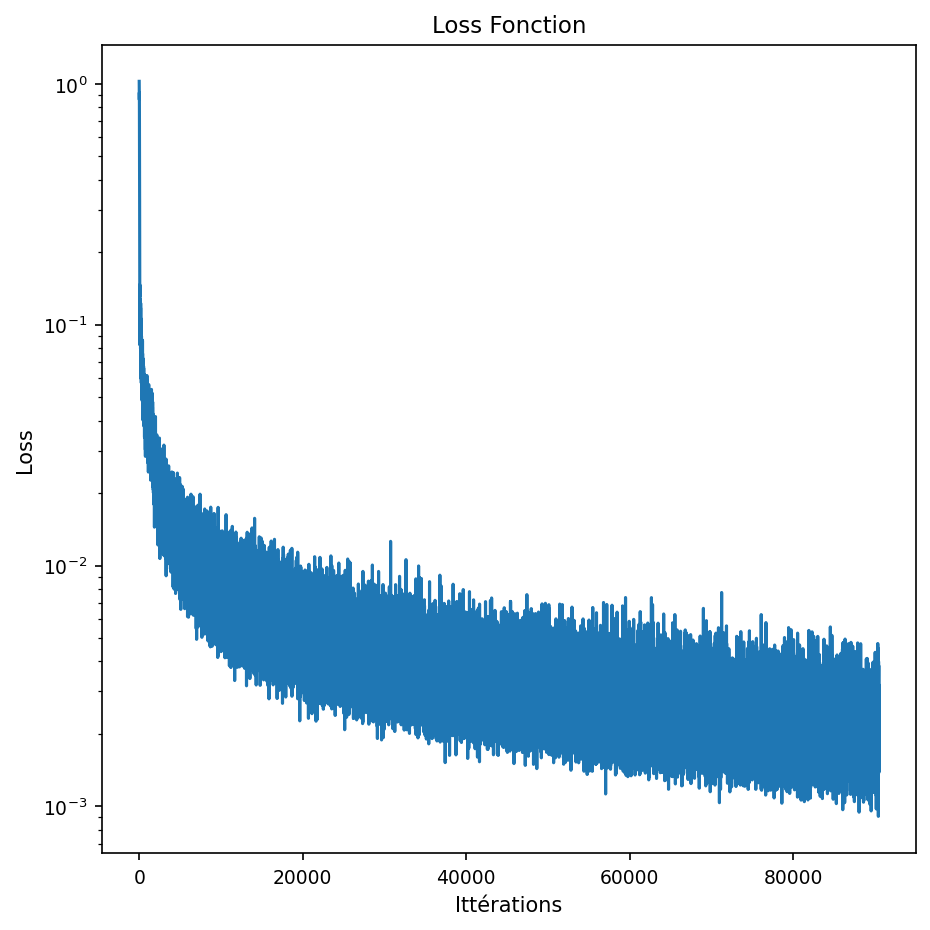

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharex=True)
ax.plot(loss_history)
ax.set_yscale('log')
ax.set_ylabel('Loss')
ax.set_xlabel('Ittérations')
ax.set_title('Loss Fonction')
plt.show()

# Génération conditionnelle de Ch sachant Ca


In [36]:
def sample_reverse(model, ca_condition, steps=TIME_STEPS, beta=BETA):
    count = ca_condition.shape[0]
    device = next(model.parameters()).device

    ca_condition = ca_condition.to(device)
    xt = torch.randn(count, TARGET_DIM, device=device)
    sample_history = [xt.detach().cpu()]

    for t in range(steps, 0, -1):
        t_feature = torch.full(
            (count, 1),
            t / steps,
            device=device,
        )

        xin = torch.cat(
            [
                xt,
                t_feature,
                ca_condition.float(),
            ],
            dim=1,
        )

        eps_pred = model(xin)

        alpha = 1 - beta
        alpha_bar = alpha ** t

        mean = (1 / np.sqrt(alpha)) * (
            xt - (beta / np.sqrt(1 - alpha_bar)) * eps_pred
        )

        if t > 1:
            noise = torch.randn_like(xt)
            xt = mean + np.sqrt(beta) * noise
        else:
            xt = mean

        sample_history.append(xt.detach().cpu())

    return torch.stack(sample_history)


In [37]:
num_generated = 5000
ca_condition = Ca[:num_generated]
real_ch = Ch[:num_generated]
original_signals = dataset[:num_generated]

samples_ch = sample_reverse(eps_model, ca_condition)
generated_ch = samples_ch[-1]

generated_j1 = torch.stack([ca_condition.cpu(), generated_ch.cpu()], dim=1)
real_j1 = torch.stack([ca_condition.cpu(), real_ch.cpu()], dim=1)

generated_signals = inverse_wavelet_transform_1d(generated_j1, wavelet=WAVELET)[:, :SIGNAL_SIZE]
exact_reconstructed_signals = inverse_wavelet_transform_1d(real_j1, wavelet=WAVELET)[:, :SIGNAL_SIZE]

exact_rmse = torch.mean((exact_reconstructed_signals - original_signals.cpu()) ** 2).sqrt()
generated_rmse = torch.mean((generated_signals - original_signals.cpu()) ** 2).sqrt()

print("Reconstruction inverse exacte Ca+Ch réel RMSE =", exact_rmse.item())
print("Reconstruction Ca réel + Ch généré RMSE       =", generated_rmse.item())


Reconstruction inverse exacte Ca+Ch réel RMSE = 6.026747456644443e-08
Reconstruction Ca réel + Ch généré RMSE       = 0.02230069972574711


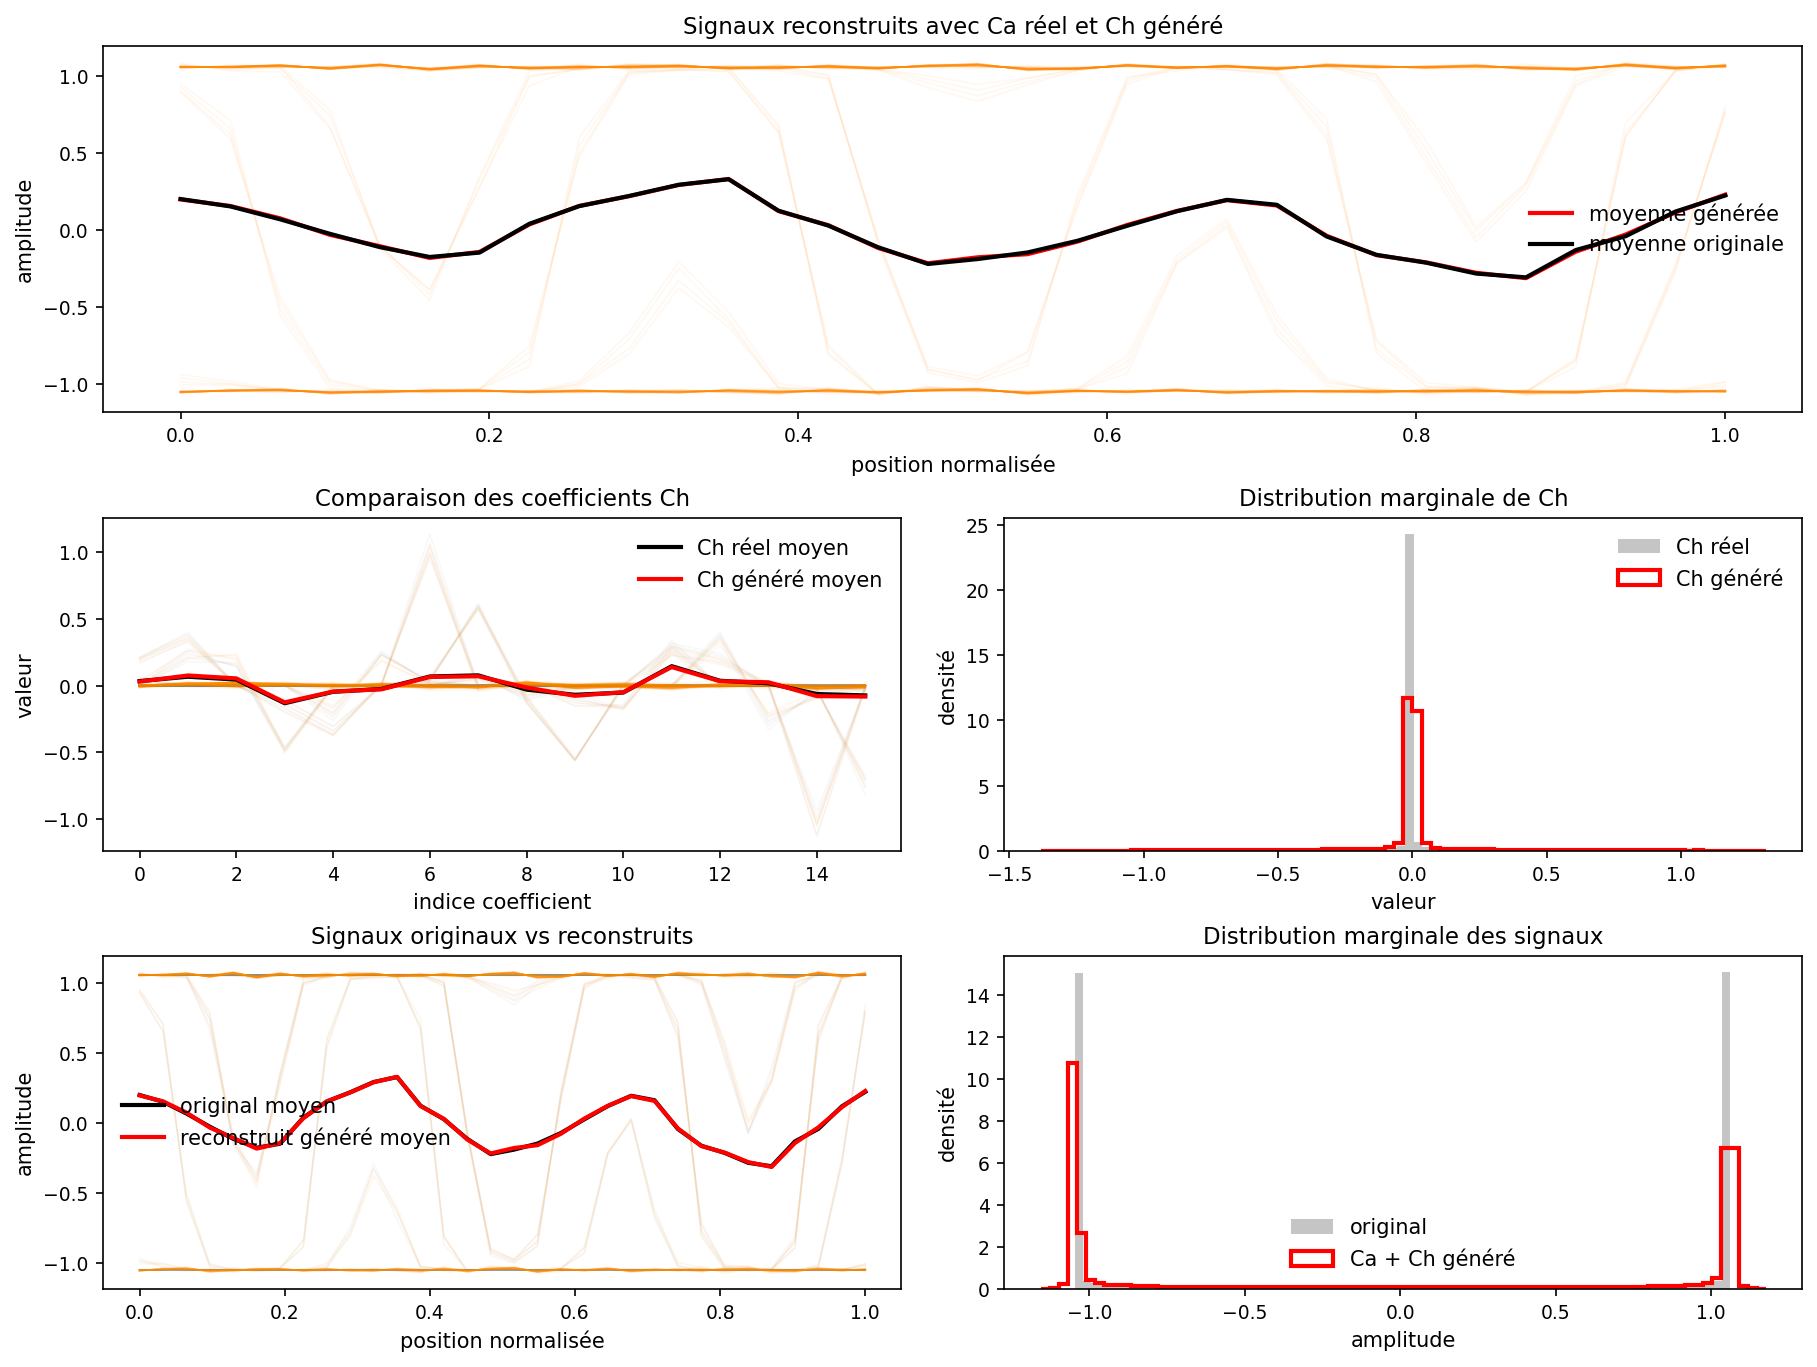

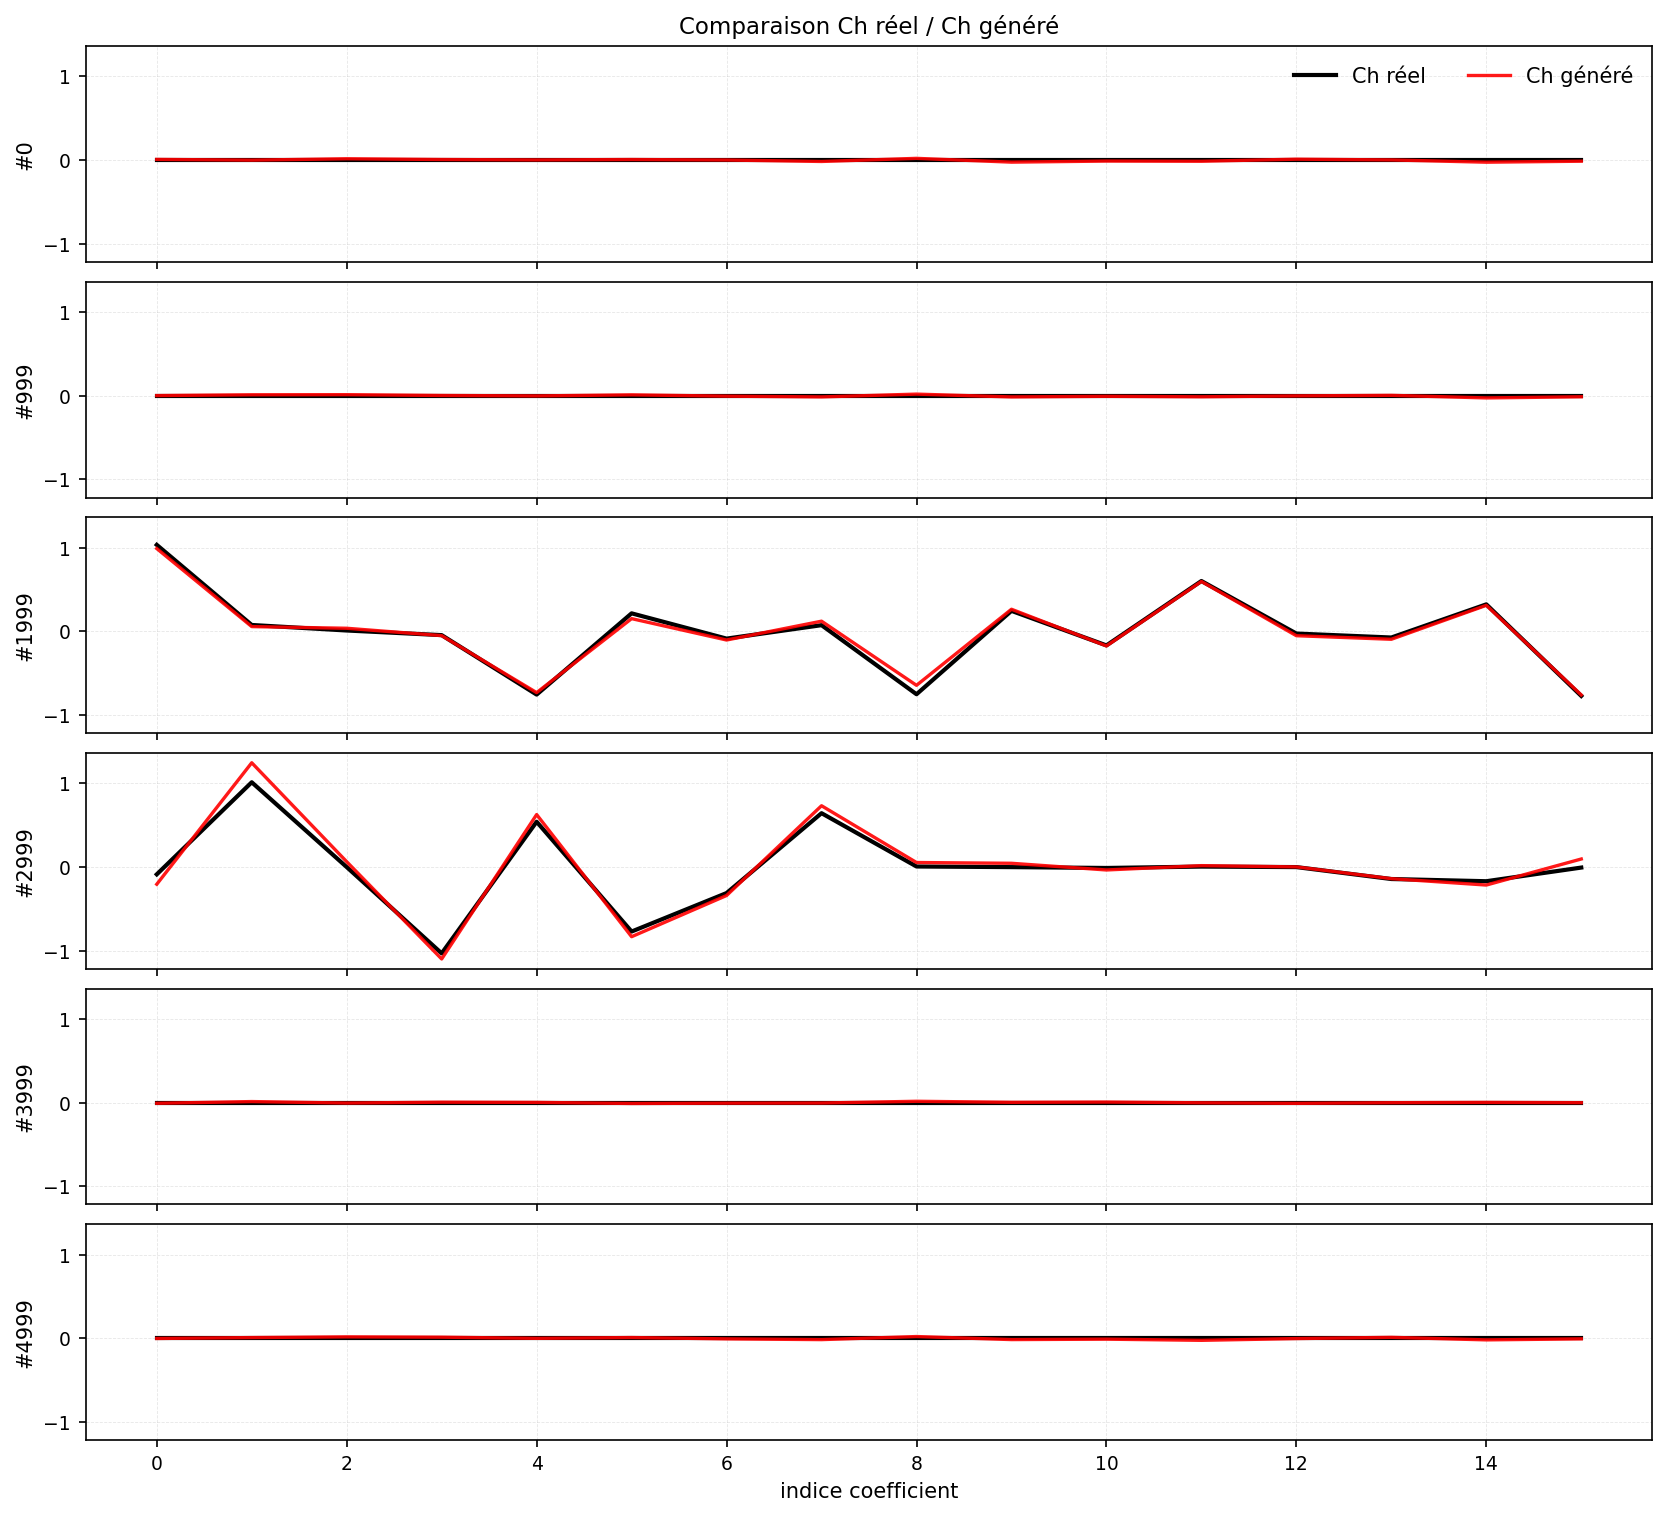

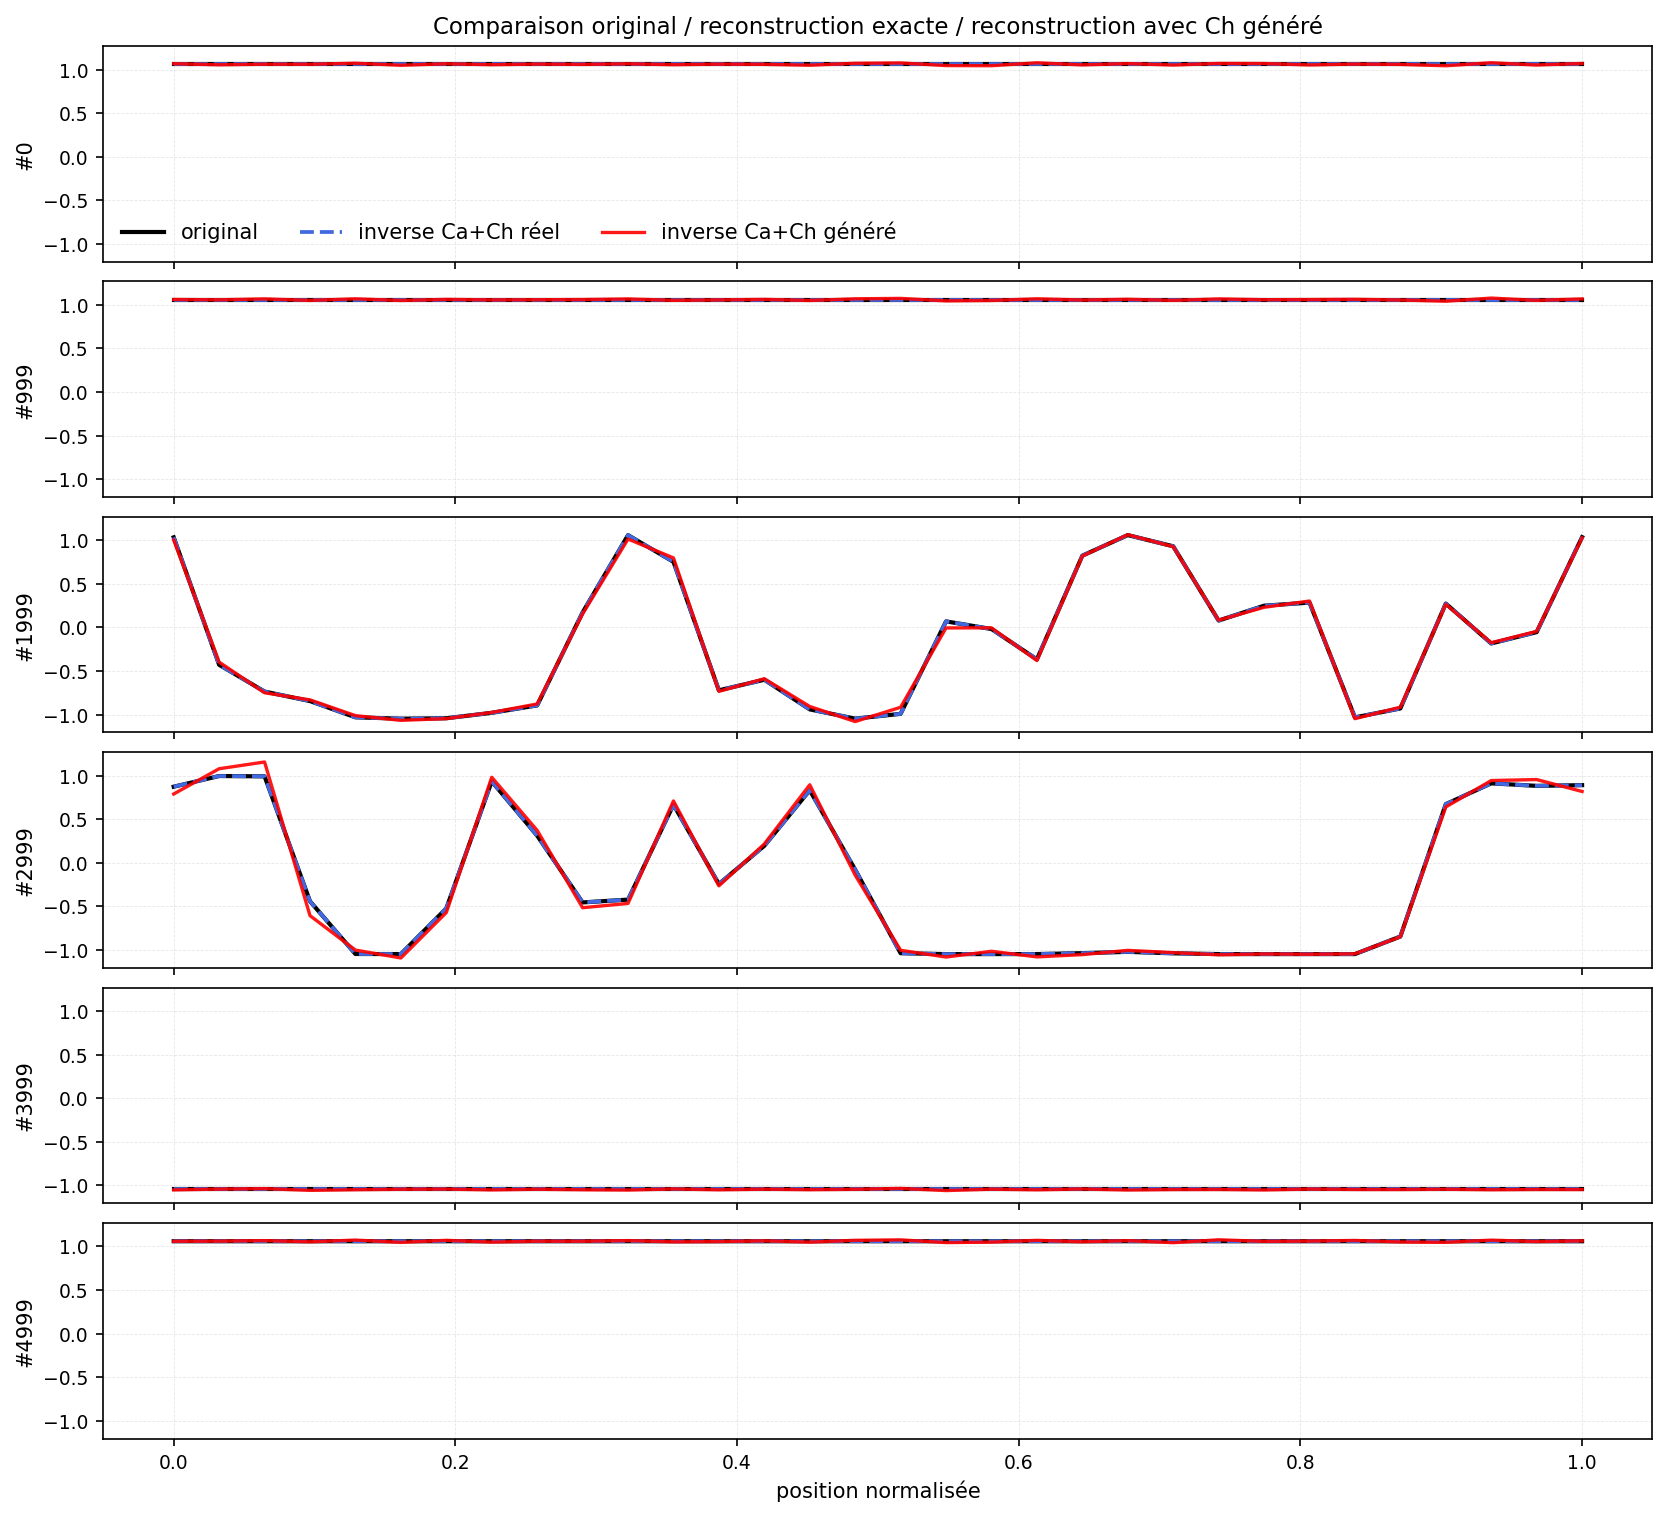

In [38]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

coef_grid = torch.arange(TARGET_DIM)
fig = plt.figure(figsize=(12, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1.0, 1.0])

ax_all = fig.add_subplot(gs[0, :])
ax_ch = fig.add_subplot(gs[1, 0])
ax_ch_dist = fig.add_subplot(gs[1, 1])
ax_signal = fig.add_subplot(gs[2, 0])
ax_signal_dist = fig.add_subplot(gs[2, 1])

ax_all.plot(grid, generated_signals[:120].T, color="darkorange", alpha=0.06, linewidth=0.8)
ax_all.plot(grid, generated_signals.mean(dim=0), color="red", linewidth=2, label="moyenne générée")
ax_all.plot(grid, original_signals[:num_generated].mean(dim=0), color="black", linewidth=2, label="moyenne originale")
ax_all.set_title("Signaux reconstruits avec Ca réel et Ch généré")
ax_all.set_xlabel("position normalisée")
ax_all.set_ylabel("amplitude")
ax_all.legend(frameon=False)

ax_ch.plot(coef_grid, real_ch[:120].T, color="gray", alpha=0.05, linewidth=0.8)
ax_ch.plot(coef_grid, generated_ch[:120].T, color="darkorange", alpha=0.06, linewidth=0.8)
ax_ch.plot(coef_grid, real_ch.mean(dim=0), color="black", linewidth=2, label="Ch réel moyen")
ax_ch.plot(coef_grid, generated_ch.mean(dim=0), color="red", linewidth=2, label="Ch généré moyen")
ax_ch.set_title("Comparaison des coefficients Ch")
ax_ch.set_xlabel("indice coefficient")
ax_ch.set_ylabel("valeur")
ax_ch.legend(frameon=False)

ax_ch_dist.hist(real_ch.flatten(), bins=80, density=True, color="gray", alpha=0.45, label="Ch réel")
ax_ch_dist.hist(generated_ch.flatten(), bins=80, density=True, histtype="step", linewidth=2, color="red", label="Ch généré")
ax_ch_dist.set_title("Distribution marginale de Ch")
ax_ch_dist.set_xlabel("valeur")
ax_ch_dist.set_ylabel("densité")
ax_ch_dist.legend(frameon=False)

ax_signal.plot(grid, original_signals[:80].T, color="gray", alpha=0.05, linewidth=0.8)
ax_signal.plot(grid, generated_signals[:80].T, color="darkorange", alpha=0.08, linewidth=0.8)
ax_signal.plot(grid, original_signals[:num_generated].mean(dim=0), color="black", linewidth=2, label="original moyen")
ax_signal.plot(grid, generated_signals.mean(dim=0), color="red", linewidth=2, label="reconstruit généré moyen")
ax_signal.set_title("Signaux originaux vs reconstruits")
ax_signal.set_xlabel("position normalisée")
ax_signal.set_ylabel("amplitude")
ax_signal.legend(frameon=False)

ax_signal_dist.hist(original_signals.flatten(), bins=80, density=True, color="gray", alpha=0.45, label="original")
ax_signal_dist.hist(generated_signals.flatten(), bins=80, density=True, histtype="step", linewidth=2, color="red", label="Ca + Ch généré")
ax_signal_dist.set_title("Distribution marginale des signaux")
ax_signal_dist.set_xlabel("amplitude")
ax_signal_dist.set_ylabel("densité")
ax_signal_dist.legend(frameon=False)

plt.show()

# Comparaison directe des Ch genérés et réels sur quelques exemples.
example_ids = torch.linspace(0, num_generated - 1, 6).long()
fig, axes = plt.subplots(len(example_ids), 1, figsize=(11, 10), sharex=True, sharey=True, constrained_layout=True)

for axis, idx in zip(axes, example_ids):
    idx = int(idx.item())
    axis.plot(coef_grid, real_ch[idx], color="black", linewidth=2, label="Ch réel")
    axis.plot(coef_grid, generated_ch[idx], color="red", linewidth=1.6, alpha=0.9, label="Ch généré")
    axis.set_ylabel(f"#{idx}")
    axis.grid(True, linestyle="--", linewidth=0.4, alpha=0.3)

axes[0].set_title("Comparaison Ch réel / Ch généré")
axes[0].legend(frameon=False, ncols=2)
axes[-1].set_xlabel("indice coefficient")
plt.show()



# Comparaison directe sur quelques exemples : original, reconstruction exacte, reconstruction générée.
example_ids = torch.linspace(0, num_generated - 1, 6).long()
fig, axes = plt.subplots(len(example_ids), 1, figsize=(11, 10), sharex=True, sharey=True, constrained_layout=True)

for axis, idx in zip(axes, example_ids):
    idx = int(idx.item())
    axis.plot(grid, original_signals[idx], color="black", linewidth=2, label="original")
    axis.plot(grid, exact_reconstructed_signals[idx], color="royalblue", linestyle="--", linewidth=1.8, label="inverse Ca+Ch réel")
    axis.plot(grid, generated_signals[idx], color="red", linewidth=1.6, alpha=0.9, label="inverse Ca+Ch généré")
    axis.set_ylabel(f"#{idx}")
    axis.grid(True, linestyle="--", linewidth=0.4, alpha=0.3)

axes[0].set_title("Comparaison original / reconstruction exacte / reconstruction avec Ch généré")
axes[0].legend(frameon=False, ncols=3)
axes[-1].set_xlabel("position normalisée")
plt.show()
